# Final results — recomb sweep at cov 10×, **v3 panel**

**Updated 2026-05-09 (afternoon).** Comparison framework on the **v3 panel** (unimputed `cn_full_231_v3` / `cn_var_231_v3`, built from the haploid-collapsed merged VCF — 80 cactus assembly genotypes + 151 PanGenie short-read calls, no Beagle imputation).

3 regimes (no skewed at cov10): **n200_g1**, **n50_g1**, **n50_g3**. Same haps and per-record truth source as the cov50 sims (mosaics deterministic from seed=42), only the read coverage differs. Truth is `recomb_truth_v3.tsv.gz` (built against cn_var_v3); cactus_em / hapFIRE TSVs **join by row index** because cn_var_v3 has multi-allelic-atomized records that share `(chrom, pos, ref_len, alt_len)`. freqk joins by `(chrom, pos, alt_len)` (per-bubble output, ref_len is the bubble's not the atomized record's).

## The 5 methods — 3-way hapFIRE diagnostic isolates panel vs projection vs method

| method | what it is | scale |
|---|---|---|
| **freqk-v3** | k-mer counting per panel SV bubble, no founder model — re-indexed on a **no-missing** v3 source VCF (`founders_231_chr.haploid.no_missing.vcf.gz`, `.`→`0/0`) | per-record |
| **cactus_em-v3 global** | k-mer Poisson EM on the v3 panel, single chrom-wide `h` (no window/anchor/smooth) | whole chrom |
| **hapfire-v2panel-v3proj** ◇ | hapFIRE on the v2 GrENE-Net SNP catalog, then output projected through `cn_var_231_v3` so it's row-aligned to truth_v3 — isolates the **projection switch** from the panel switch | 10 kb |
| **hapfire-v3panel** ★ | hapFIRE on the v3 SNP-only Chr1 panel, fake-phased homozygous-diploid carrier-status — isolates the **full v3-panel switch** | 10 kb |
| **cactus_em-v3 window+λ+smooth** ★★ | cactus_em on v3 panel: window-mode @ 10 kb + Dirichlet anchor toward `h_global` + post-EM Li-Stephens HMM smoothing — **production recipe** | **10 kb** |

◇ The v2 panel is fully phased (Beagle-imputed GrENE-Net SNP catalog) and has 0 dup-pos rows. After projection through `cn_var_231_v3`, this column holds the **panel** axis fixed at the clean v2 panel and only switches the **projection** matrix.

★ The v3-panel hapFIRE is a *diagnostic* — the unphased multi-allelic v3 panel cannot be cleanly consumed by hapFIRE. The conversion pipeline (3 structural fixes: phasing collapse, dedup-by-position, IUPAC-N reference) is in `sims/visor_freqk/chr1_only_panel_v3/README.md`. The carrier-status collapse maps ~0.79 % PG het cells to `1|1` — diagnostic only, not a true apples-to-apples; production hapFIRE keeps the v2 GrENE-Net SNP catalog.

★★ Production recipe: `--block-mode window --window-bp 10000 --global-anchor-weight 0.3 --hmm-smooth-passes 5 --hmm-smooth-alpha 0.5`.

**hapfire_coarse dropped** from this version — was always empty (xwu's full hapFIRE pipeline was not re-run at cov10 in either v2 or v3); no information added by carrying the column.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.cm as cm

ROOT = Path('/global/scratch/users/tbellg/kmate')
SIMS = ROOT / 'sims/visor_freqk'

REGIMES = {
    'n200_g1_cov10':       SIMS / 'pool_sweep_82_recomb' / 'cov10_n200_g1_s42_hotspots_p231_chr1',
    'n50_g1_cov10':        SIMS / 'pool_sweep_82_recomb' / 'cov10_n50_g1_s42_hotspots_p231_chr1',
    'n50_g3_cov10':        SIMS / 'pool_sweep_82_recomb' / 'cov10_n50_g3_s42_hotspots_p231_chr1',
    'n50_g3_skewed_cov10': SIMS / 'pool_sweep_82_recomb_skewed' / 'cov10_n50_g3_s42_hotspots_dom500_p231_chr1',
}
REGIME_LABELS = {
    'n200_g1_cov10':       'n200_g1\n(easy)',
    'n50_g1_cov10':        'n50_g1\n(med)',
    'n50_g3_cov10':        'n50_g3\n(hard, mosaic)',
    'n50_g3_skewed_cov10': 'n50_g3 skewed\n(dom500, stress)',
}

# 'rowidx' methods are row-aligned to cn_var_v3 (TSV row k <-> truth row k).
# 'freqk' joins by (chrom, pos+2, alt_len) -- freqk reports VCF_pos - 2 per
# the feedback memory; we add 2 before merging.
METHODS = ['freqk', 'global', 'hapfire_coarse_v3proj', 'hapfire_v2panel_v3proj', 'hapfire_v3panel', 'window_10kb_smooth']
METHOD_FILES = {
    'freqk':                  ('chrompos', 'freqk_v3_per_record.tsv.gz'),
    'global':                 ('rowidx',   'cactus_em_recomb_GLOBAL_v3.tsv'),
    'hapfire_v2panel_v3proj': ('rowidx',   'hapfire_v2panel_v3proj_win10kb_perblock_proj.tsv'),
    'hapfire_v3panel':        ('rowidx',   'hapfire_v3_win10kb_perblock_proj.tsv'),
    'hapfire_coarse_v3proj':  ('rowidx',   'hapfire_coarse_v3proj_perblock_proj.tsv'),
    'window_10kb_smooth':     ('rowidx',   'cactus_em_recomb_window_10kb_anchor0.3_smooth5a05_v3.tsv'),
}
METHOD_LABELS = {
    'freqk':                  'freqk-v3 (key=ref/alt)',
    'global':                 'cactus_em-v3 global (chrom-wide h)',
    'hapfire_v2panel_v3proj': 'hapfire-v2-panel WINDOW 10kb ◇',
    'hapfire_v3panel':        'hapfire-v3-panel WINDOW 10kb ★',
    'hapfire_coarse_v3proj':  'hapfire-v2-panel COARSE (per-chrom h) ◆',
    'window_10kb_smooth':     'cactus_em-v3 WINDOW 10kb + λ=0.3 + smooth ★★',
}

# Sidecar: row-aligned (chrom, pos, ref, alt) for cn_var_v3, joining freqk by alt.
# Built once via `bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' founders_231_chr.haploid.vcf.gz`.
# We merge freqk on (chrom, pos, alt) — NOT (chrom, pos, ref, alt) — because
# freqk's REF is the bubble multi-base string while truth's REF is the per-variant
# REF (single char for SNPs). The ALT character matches between the two for SNPs
# (and for the subset of SVs whose freqk-bubble-ALT happens to equal the VCF-atomized-ALT).
REF_ALT_SIDECAR = ROOT / 'data/cn_var_231_v3.ref_alt.tsv.gz'
ref_alt = pd.read_csv(REF_ALT_SIDECAR, sep='\t', header=None, names=['chrom','pos','ref','alt'])


def load_regime(work: Path) -> pd.DataFrame:
    truth = pd.read_csv(work / 'recomb_truth_v3.tsv.gz', sep='\t', compression='gzip')
    base = truth[['chrom', 'pos', 'ref_len', 'alt_len', 'truth_af']].copy()
    n = len(base)
    if len(ref_alt) != n:
        print(f'WARN: ref_alt sidecar rows {len(ref_alt):,} != truth rows {n:,}')
    base['alt'] = ref_alt['alt'].to_numpy()
    for m in METHODS:
        join_kind, fname = METHOD_FILES[m]
        f = work / fname
        if not f.exists():
            print(f'  {m:<28s} MISSING ({fname})')
            base[m] = np.nan
            continue
        if join_kind == 'rowidx':
            df = pd.read_csv(f, sep='\t')
            if len(df) != n:
                print(f'  {m:<28s} ROW MISMATCH: {len(df)} vs cn_var_v3 {n}')
                base[m] = np.nan
                continue
            base[m] = df['alt_freq'].astype(np.float32).to_numpy()
        elif join_kind == 'chrompos':
            df = pd.read_csv(f, sep='\t')
            af_col = 'freqk_af' if 'freqk_af' in df.columns else 'alt_freq'
            # freqk reports VCF_pos - 2; correct first.
            df['pos'] = df['pos'].astype(np.int64) + 2
            # Restrict to Chr1: sims are Chr1-only but freqk indexes the full VCF;
            # cross-chrom k-mer collisions otherwise leak ~10k spurious "predictions"
            # into the Chr2-5 record set, which the other (read-driven) methods
            # don't produce. Apples-to-apples requires Chr1-only freqk.
            df = df[df.chrom == 'Chr1']
            # Merge on (chrom, pos, alt). Critical: drop ref because freqk's ref
            # is the bubble (multi-base), VCF's is the per-variant REF. ALT char
            # matches for SNPs and atomization-aligned SV ALTs. Without alt in
            # the key, distinct ALTs at the same pos collapse to mean=0.5.
            df = df[['chrom', 'pos', 'alt', af_col]].rename(columns={af_col: m})
            base = base.merge(df, on=['chrom', 'pos', 'alt'], how='left')
    base['var_type'] = np.where(
        (base.ref_len == 1) & (base.alt_len == 1), 'SNP',
        np.where(base.alt_len > base.ref_len, 'INS',
                 np.where(base.ref_len > base.alt_len, 'DEL', 'COMPLEX')))
    return base


regime_data = {}
for r, work in REGIMES.items():
    print(f'Loading {r}...')
    regime_data[r] = load_regime(work)

for r in regime_data:
    df = regime_data[r]
    poly_mask = (df.truth_af > 0) & (df.truth_af < 1)
    regime_data[r] = df[poly_mask].copy()

print('\nPer-regime polymorphic record count:')
for r, df in regime_data.items():
    print(f'  {r:<16s}  total={len(df):>9,}  SNP={(df.var_type=="SNP").sum():>8,}  '
          f'INS={(df.var_type=="INS").sum():>7,}  DEL={(df.var_type=="DEL").sum():>7,}')

print('\nPer-method polymorphic-with-pred count (not-NaN), n50_g3:')
df = regime_data['n50_g3_cov10']
for m in METHODS:
    print(f'  {m:<28s}  n_pred={int(df[m].notna().sum()):>8,}')

Loading n200_g1_cov10...


Loading n50_g1_cov10...


Loading n50_g3_cov10...


Loading n50_g3_skewed_cov10...



Per-regime polymorphic record count:


  n200_g1_cov10     total=4,587,288  SNP=2,377,991  INS=593,598  DEL=623,095


  n50_g1_cov10      total=3,129,411  SNP=1,647,932  INS=374,109  DEL=444,047


  n50_g3_cov10      total=2,716,153  SNP=1,441,271  INS=319,409  DEL=384,270


  n50_g3_skewed_cov10  total=2,716,153  SNP=1,441,271  INS=319,409  DEL=384,270

Per-method polymorphic-with-pred count (not-NaN), n50_g3:
  freqk                         n_pred= 132,471
  global                        n_pred= 671,114
  hapfire_coarse_v3proj         n_pred= 671,114
  hapfire_v2panel_v3proj        n_pred= 635,805
  hapfire_v3panel               n_pred= 666,744
  window_10kb_smooth            n_pred= 671,114


## Headline R² table

Per-record alt-AF R² vs truth_v3 on Chr1 polymorphic records, by `var_type` and regime. Higher = better. Best per (regime, var_type) cell highlighted by green-on-RdYlGn gradient.

In [2]:
def metrics(t: np.ndarray, p: np.ndarray) -> dict:
    f = np.isfinite(t) & np.isfinite(p)
    t, p = t[f], p[f]
    if len(t) < 5 or t.std() == 0 or p.std() == 0:
        return dict(n=int(len(t)), R2=np.nan, MAE=np.nan, slope=np.nan)
    err = p - t
    r = np.corrcoef(t, p)[0, 1]
    slope = np.polyfit(t, p, 1)[0]
    return dict(n=int(len(t)), R2=float(r * r),
                MAE=float(np.mean(np.abs(err))), slope=float(slope))


rows = []
for r, df in regime_data.items():
    for vt in ['SNP', 'INS', 'DEL']:
        sub = df[df.var_type == vt]
        for m in METHODS:
            mres = metrics(sub.truth_af.to_numpy(), sub[m].to_numpy())
            rows.append({'regime': r, 'var_type': vt, 'method': m, **mres})
summary = pd.DataFrame(rows)

headline = summary.pivot_table(index='regime', columns=['method', 'var_type'], values='R2')
headline = headline.reindex(list(REGIMES.keys()))
headline = headline.reindex(
    columns=pd.MultiIndex.from_product([METHODS, ['SNP', 'INS', 'DEL']],
                                        names=['method', 'var_type']))
headline.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}', na_rep='—')

## hapFIRE 3-way breakdown — where is the accuracy leaking?

Three configs share method (hapFIRE @ 10 kb fixed-window) but differ in panel/projection:

| config | panel | projection | what it isolates |
|---|---|---|---|
| **v2-panel + v2-proj** | v2 GrENE-Net (clean baseline) | `cn_var_231_v2` | original baseline |
| **v2-panel + v3-proj** ◇ | v2 GrENE-Net (clean baseline) | `cn_var_231_v3` | pure projection switch |
| **v3-panel + v3-proj** ★ | v3 fake-phased + dedup'd | `cn_var_231_v3` | full v3 path |

The Δ between cells localizes whether accuracy lives in the panel switch or the projection switch.

In [3]:
# 3-way breakdown: SNP-only (hapFIRE structurally can't do SVs).
V2_TRUTH_FILE = 'recomb_truth.tsv.gz'
V2_HF_FILE    = 'hapfire_win10kb_perblock_proj.tsv'

three_way_rows = []
for r, work in REGIMES.items():
    if (work / V2_TRUTH_FILE).exists() and (work / V2_HF_FILE).exists():
        truth_v2 = pd.read_csv(work / V2_TRUTH_FILE, sep='\t', compression='gzip')
        hf_v2 = pd.read_csv(work / V2_HF_FILE, sep='\t')
        if len(hf_v2) == len(truth_v2):
            mask = (truth_v2.truth_af > 0) & (truth_v2.truth_af < 1) & (truth_v2.ref_len == 1) & (truth_v2.alt_len == 1)
            mres = metrics(truth_v2.truth_af[mask].to_numpy(),
                           hf_v2['alt_freq'].astype(np.float32)[mask].to_numpy())
            three_way_rows.append({'regime': r, 'config': '(a) v2-panel + v2-proj', **mres})
    df = regime_data[r]
    sub = df[df.var_type == 'SNP']
    mres = metrics(sub.truth_af.to_numpy(), sub['hapfire_v2panel_v3proj'].to_numpy())
    three_way_rows.append({'regime': r, 'config': '(b) v2-panel + v3-proj ◇', **mres})
    mres = metrics(sub.truth_af.to_numpy(), sub['hapfire_v3panel'].to_numpy())
    three_way_rows.append({'regime': r, 'config': '(c) v3-panel + v3-proj ★', **mres})

three_way = pd.DataFrame(three_way_rows)
pivot = three_way.pivot_table(index='regime', columns='config', values='R2').reindex(list(REGIMES.keys()))
print(pivot.round(3))
print()

a_col = [c for c in pivot.columns if c.startswith('(a)')][0]
b_col = [c for c in pivot.columns if c.startswith('(b)')][0]
c_col = [c for c in pivot.columns if c.startswith('(c)')][0]
print('Delta projection (b - a):', [round(pivot.loc[r, b_col] - pivot.loc[r, a_col], 3) for r in REGIMES])
print('Delta panel      (c - b):', [round(pivot.loc[r, c_col] - pivot.loc[r, b_col], 3) for r in REGIMES])

pivot.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}', na_rep='—')

config               (a) v2-panel + v2-proj  (b) v2-panel + v3-proj ◇  \
regime                                                                  
n200_g1_cov10                         0.869                     0.885   
n50_g1_cov10                          0.802                     0.813   
n50_g3_cov10                          0.718                     0.728   
n50_g3_skewed_cov10                   0.610                     0.621   

config               (c) v3-panel + v3-proj ★  
regime                                         
n200_g1_cov10                           0.886  
n50_g1_cov10                            0.812  
n50_g3_cov10                            0.712  
n50_g3_skewed_cov10                     0.604  

Delta projection (b - a): [0.016, 0.011, 0.01, 0.011]
Delta panel      (c - b): [0.001, -0.002, -0.015, -0.017]


config,(a) v2-panel + v2-proj,(b) v2-panel + v3-proj ◇,(c) v3-panel + v3-proj ★
regime,,,
n200_g1_cov10,0.869,0.885,0.886
n50_g1_cov10,0.802,0.813,0.812
n50_g3_cov10,0.718,0.728,0.712
n50_g3_skewed_cov10,0.610,0.621,0.604


## SNP — truth-vs-estimate hexbin grid

Each row = method, each column = regime. Diagonal `y = x` is the reference. Color = log-density of records in that bin. Cell label gives R², slope, MAE, and number of polymorphic records.

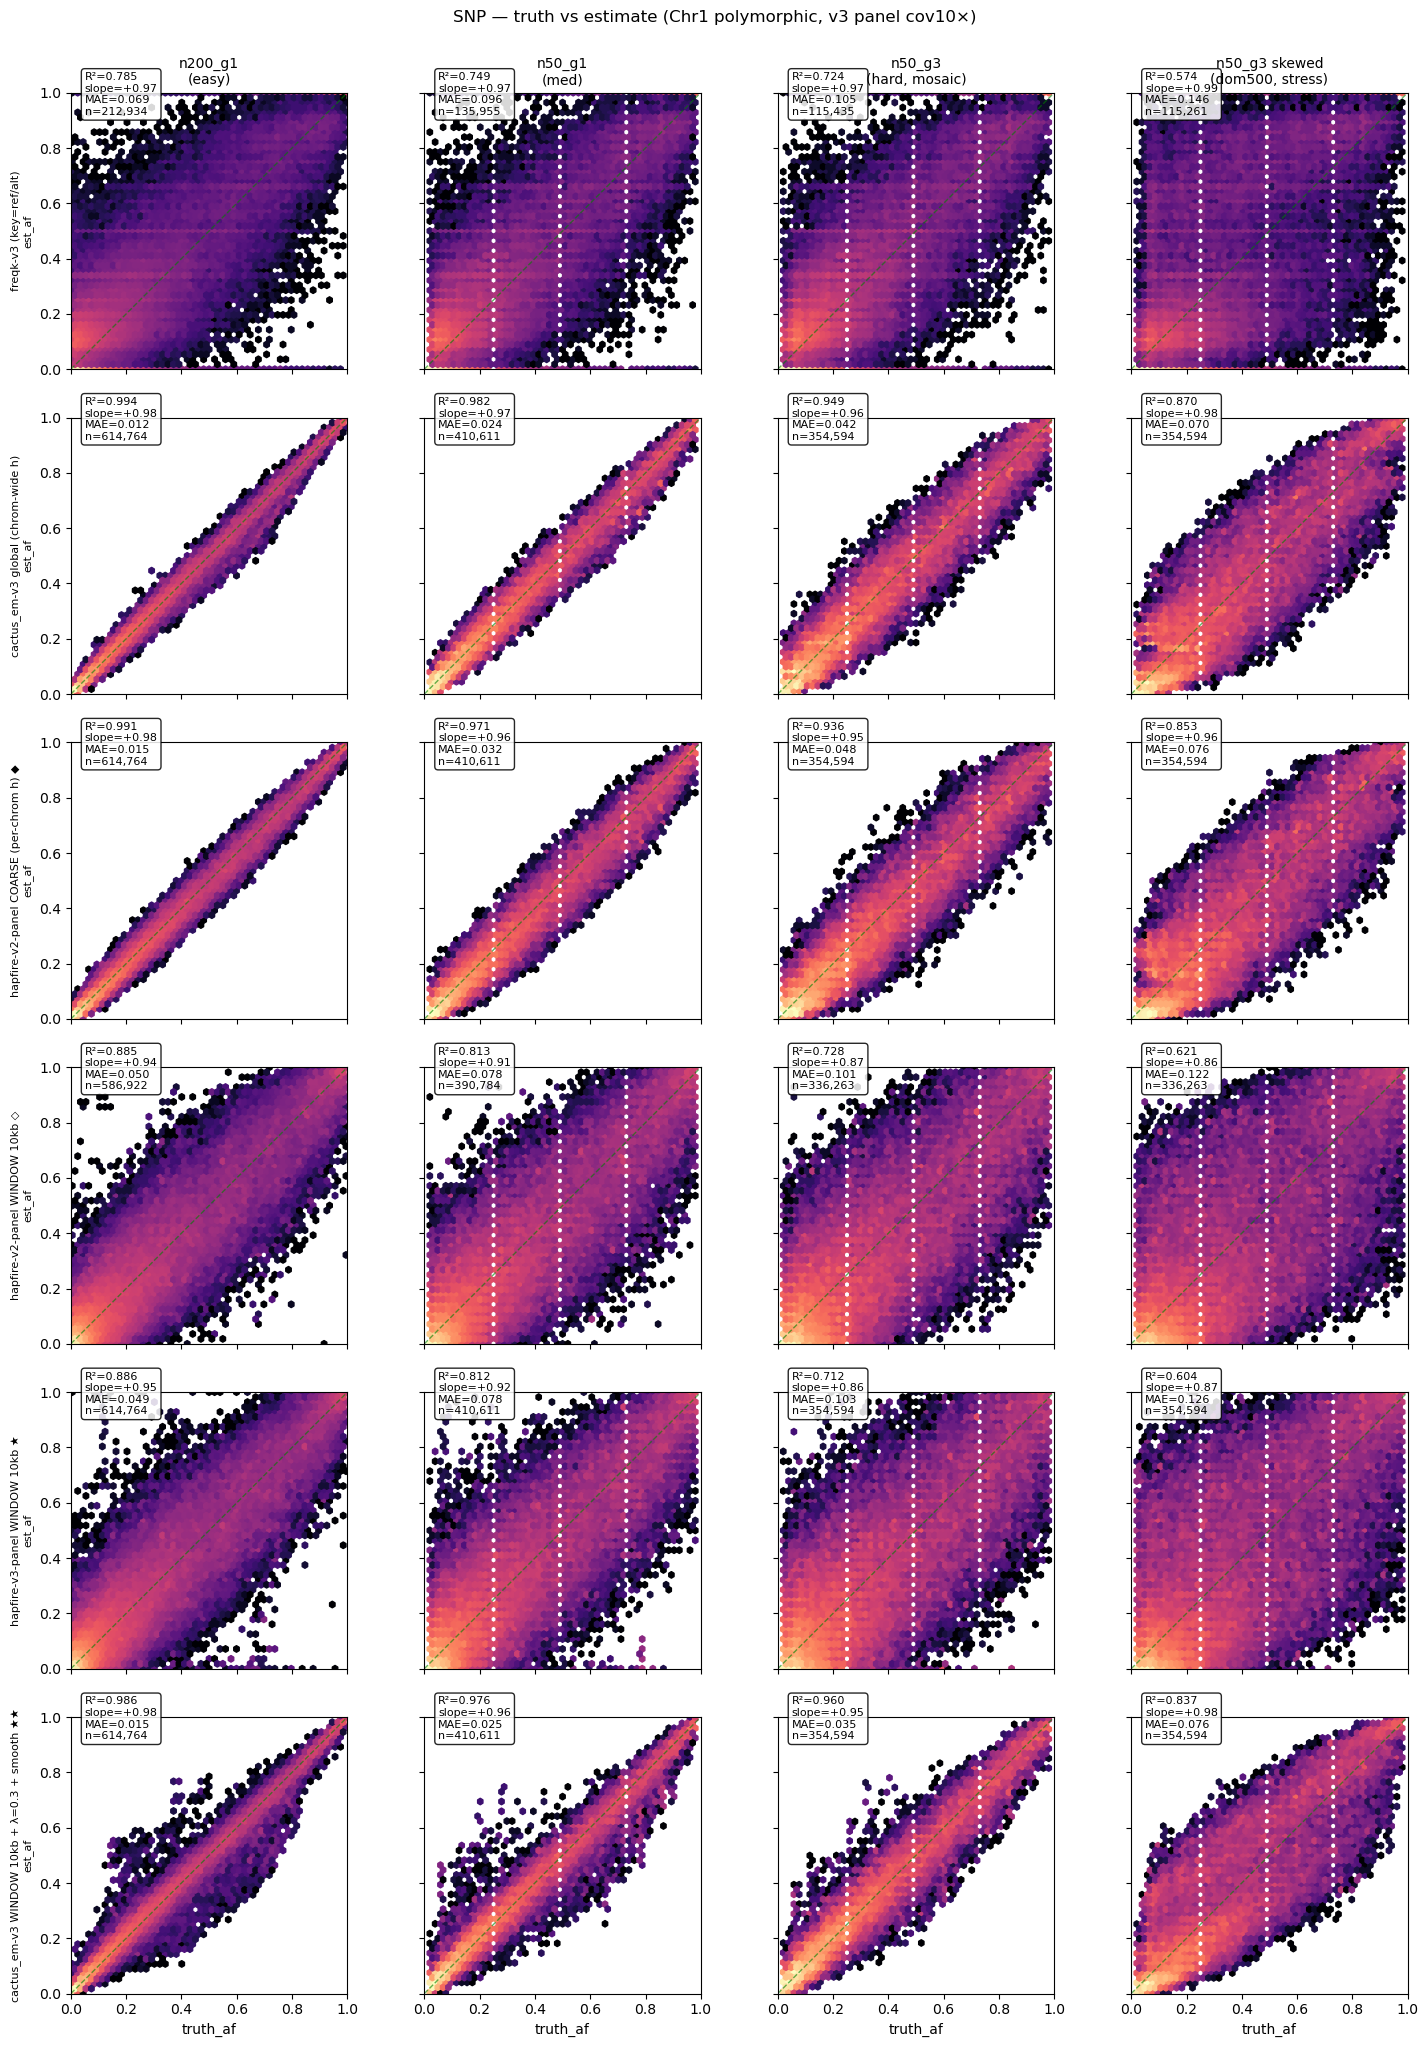

In [4]:
def hexgrid(var_filter, title, min_size=None, max_size=None):
    fig, axes = plt.subplots(len(METHODS), len(REGIMES),
                              figsize=(3.7 * len(REGIMES), 3.4 * len(METHODS)),
                              sharex=True, sharey=True)
    for i, m in enumerate(METHODS):
        for j, r in enumerate(REGIMES):
            ax = axes[i, j]
            ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
            if i == 0: ax.set_title(REGIME_LABELS[r], fontsize=10)
            if j == 0: ax.set_ylabel(f'{METHOD_LABELS[m]}\nest_af', fontsize=8)
            if i == len(METHODS) - 1: ax.set_xlabel('truth_af')
            df = regime_data[r]
            sub = df[var_filter(df)]
            sz = (sub.ref_len - sub.alt_len).abs()
            if min_size is not None:
                sub = sub[sz >= min_size]; sz = (sub.ref_len - sub.alt_len).abs()
            if max_size is not None:
                sub = sub[sz < max_size]
            sub = sub.dropna(subset=[m])
            if len(sub) < 5:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=10, color='gray')
                continue
            ax.hexbin(sub.truth_af, sub[m], gridsize=50, cmap='magma',
                      norm=LogNorm(), mincnt=1)
            ax.plot([0, 1], [0, 1], 'g--', lw=1, alpha=0.6)
            mres = metrics(sub.truth_af.to_numpy(), sub[m].to_numpy())
            label = (f"R²={mres['R2']:.3f}\nslope={mres['slope']:+.2f}\n"
                     f"MAE={mres['MAE']:.3f}\nn={mres['n']:,}") if not np.isnan(mres['R2']) else 'no data'
            ax.text(0.05, 0.92, label,
                    transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    fig.suptitle(title, y=1.001)
    fig.tight_layout(); plt.show()


hexgrid(lambda d: d.var_type == 'SNP',
        'SNP — truth vs estimate (Chr1 polymorphic, v3 panel cov10×)')

## Big insertions (≥50 bp)

hapFIRE rows show degraded R² on big-INS — hapFIRE is per-base SNP-only by construction; the SV signal in the projector comes from the founder × cn_var_v3 matrix mapping each window's `h` onto SV records. cactus_em rows show the full v3 INS coverage. (freqk-v3 still misbehaves — see Bottom line.)

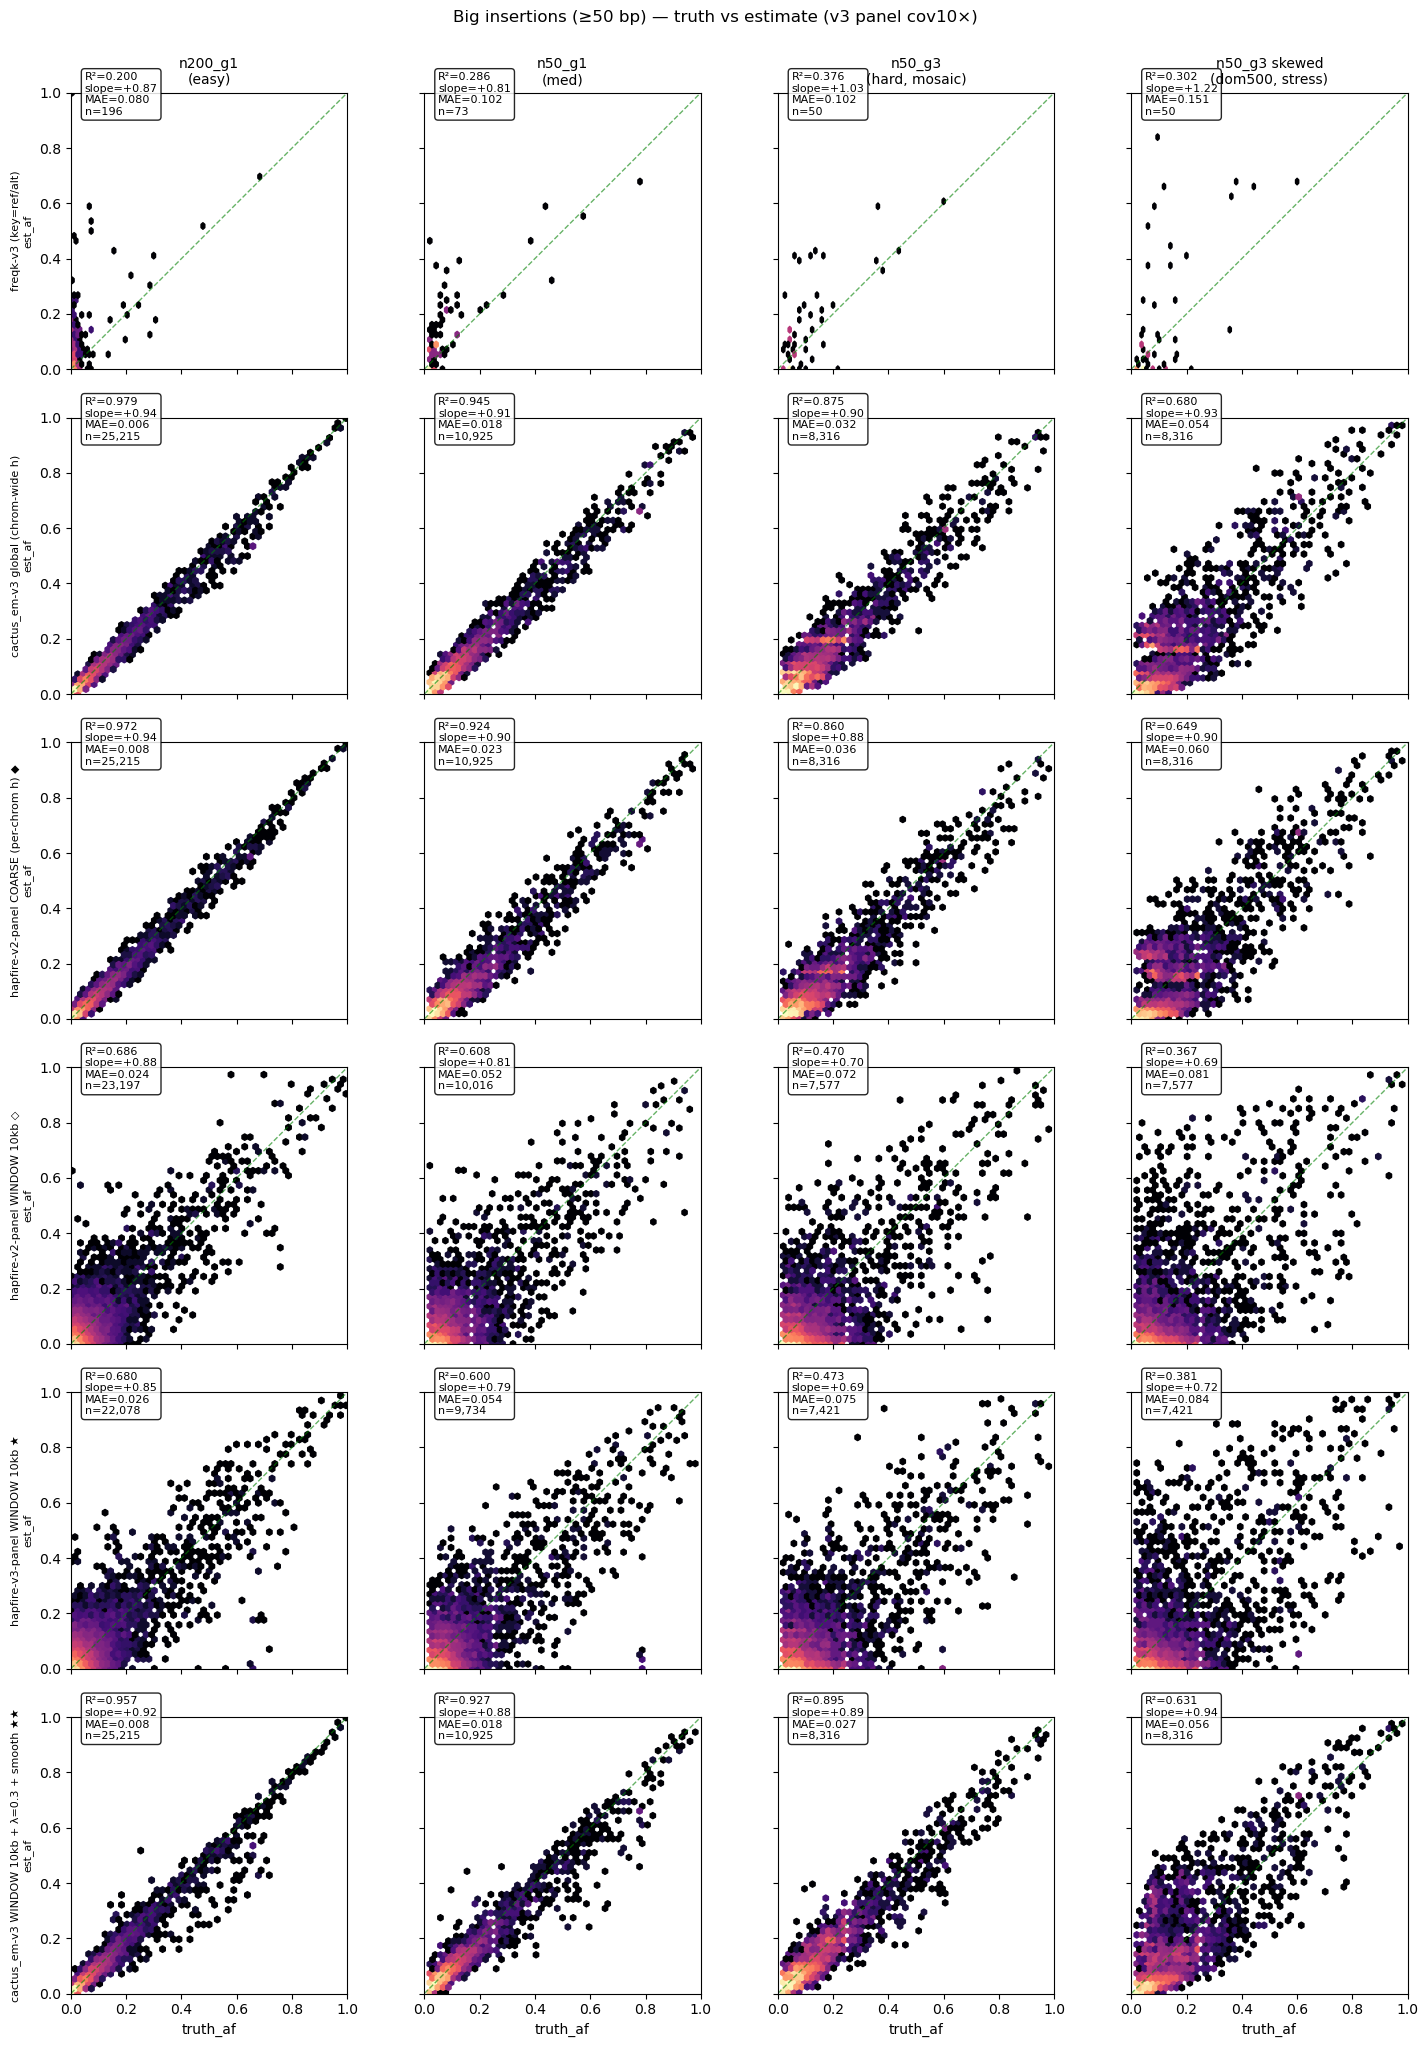

In [5]:
hexgrid(lambda d: d.var_type == 'INS',
        'Big insertions (≥50 bp) — truth vs estimate (v3 panel cov10×)',
        min_size=50)

## Big deletions (≥50 bp)

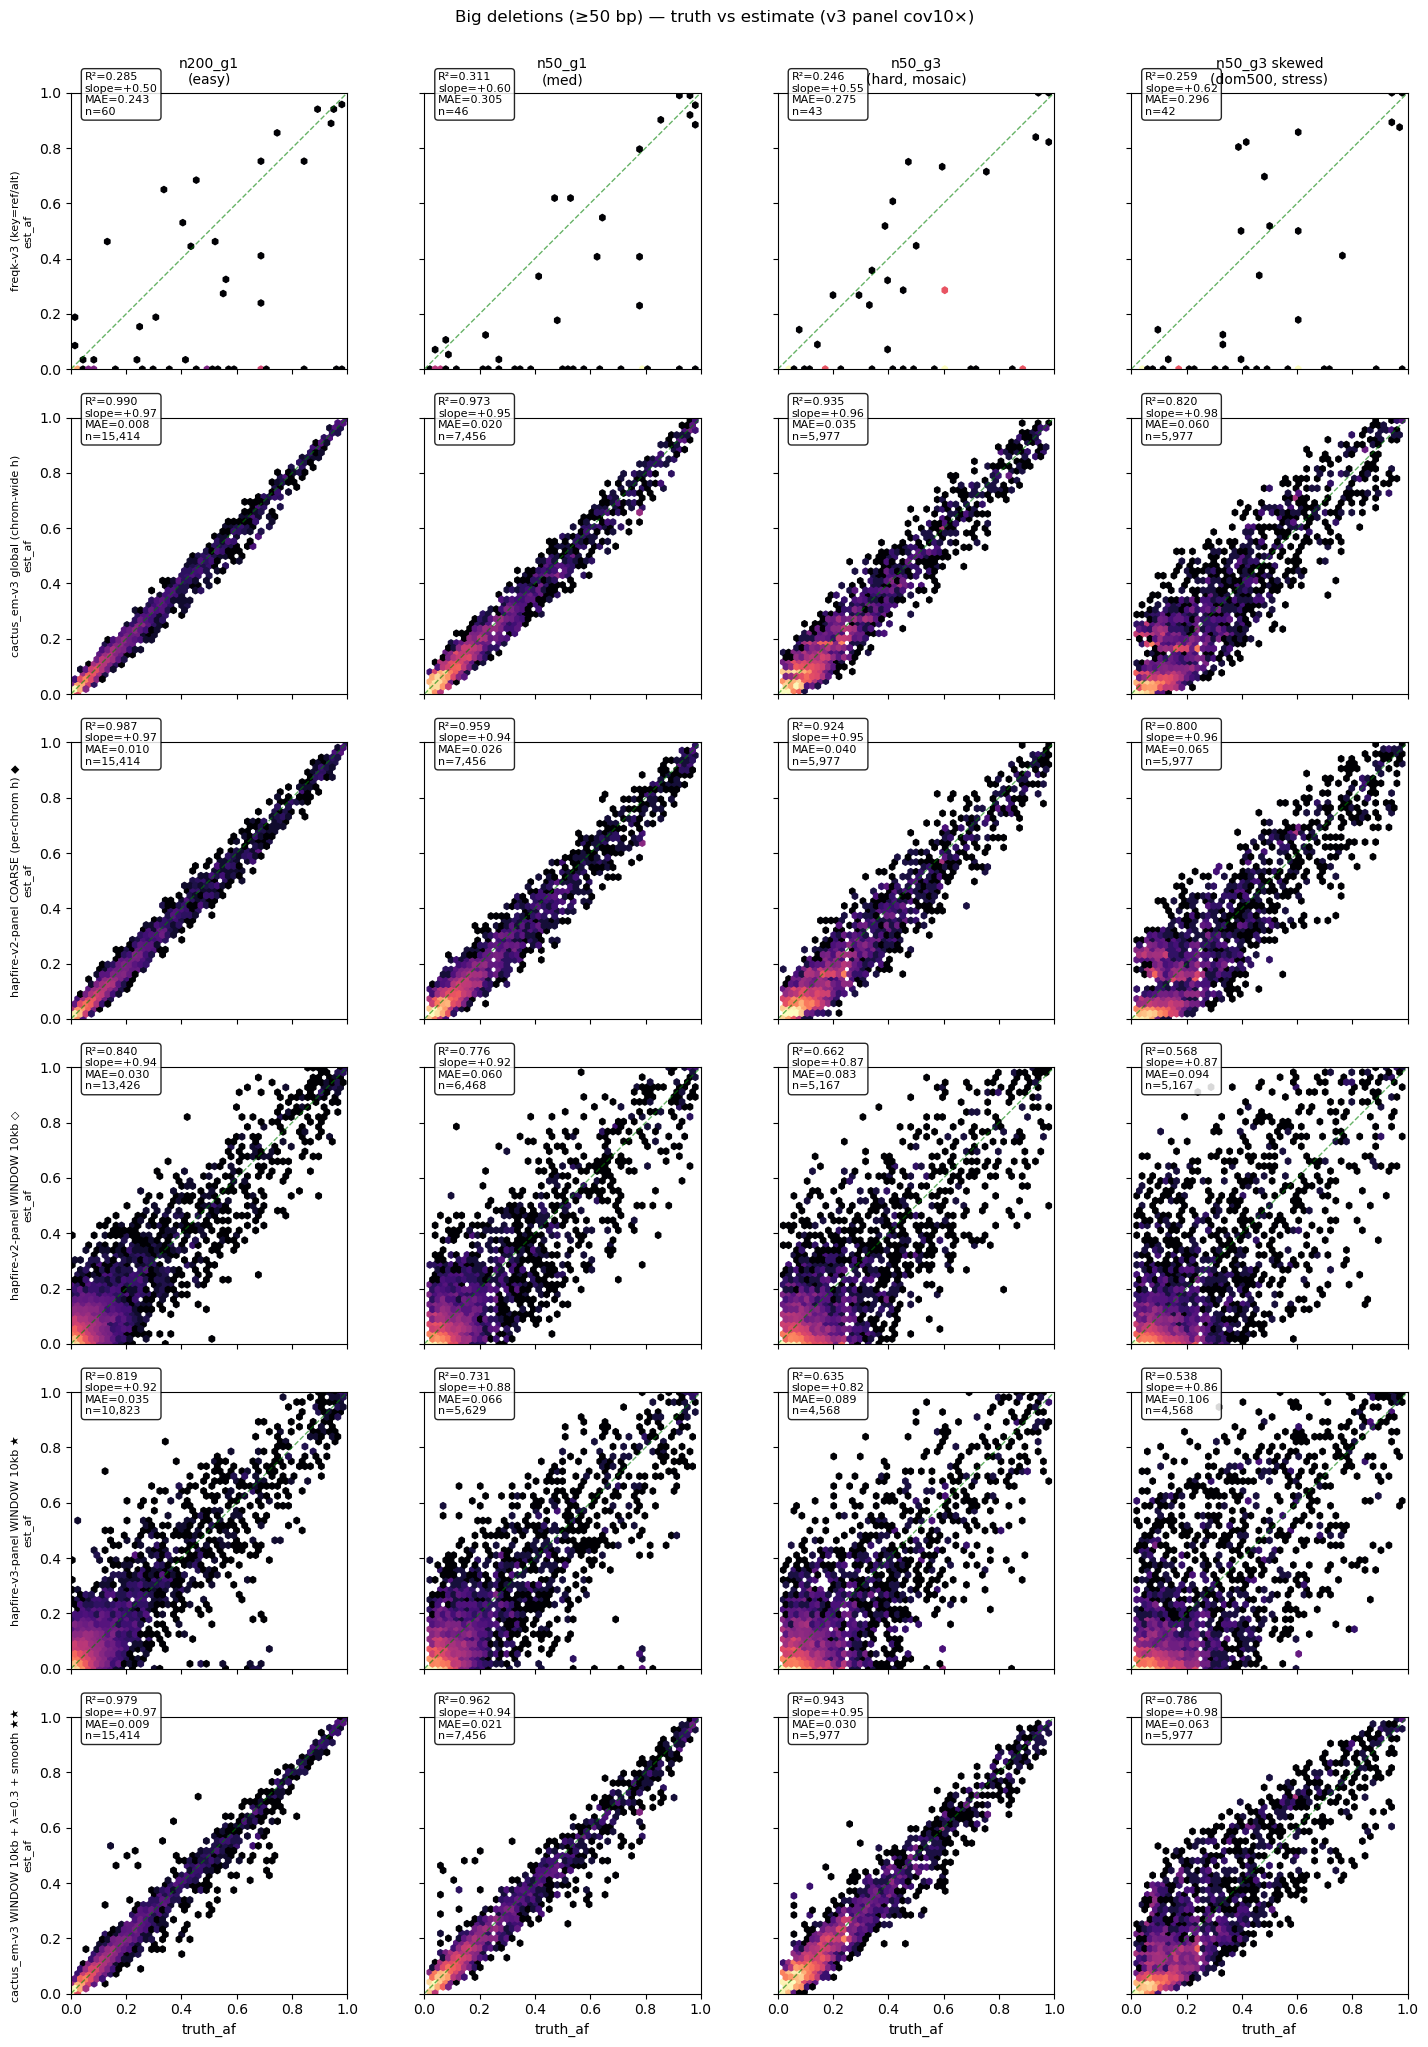

In [6]:
hexgrid(lambda d: d.var_type == 'DEL',
        'Big deletions (≥50 bp) — truth vs estimate (v3 panel cov10×)',
        min_size=50)

## Small insertions (2–49 bp)

The middle layer between SNPs (1bp/1bp) and big SVs (≥50 bp). These are PanGenie-detectable small indels that don't appear in either the SNP or the big-SV hexgrids.


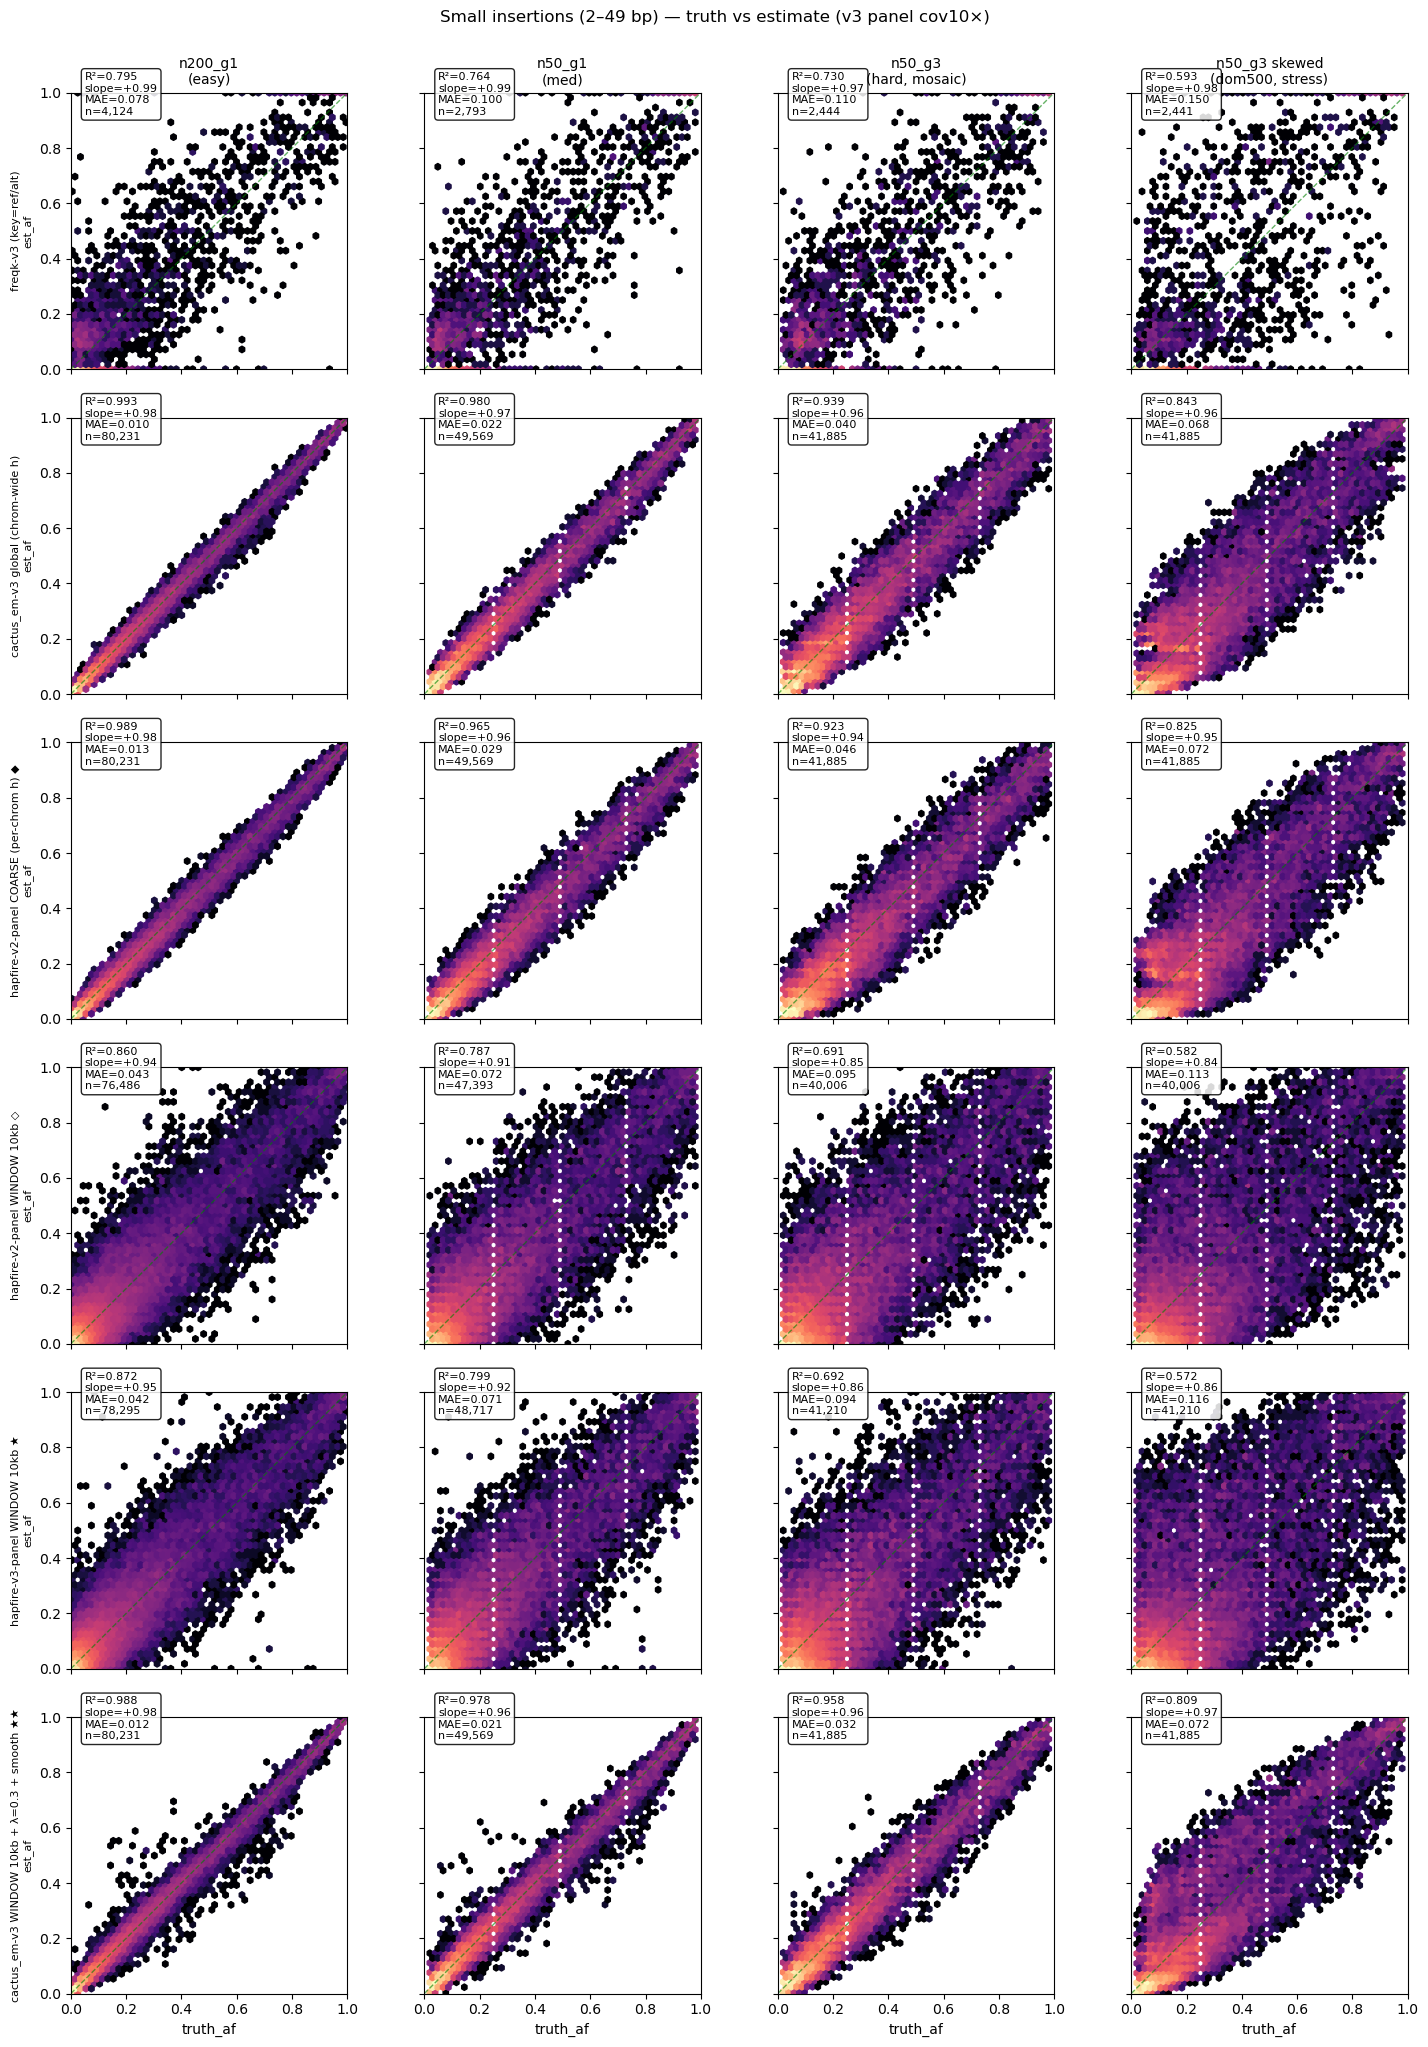

In [7]:
hexgrid(lambda d: d.var_type == 'INS',
        'Small insertions (2–49 bp) — truth vs estimate (v3 panel cov10×)',
        min_size=2, max_size=50)


## Small deletions (2–49 bp)


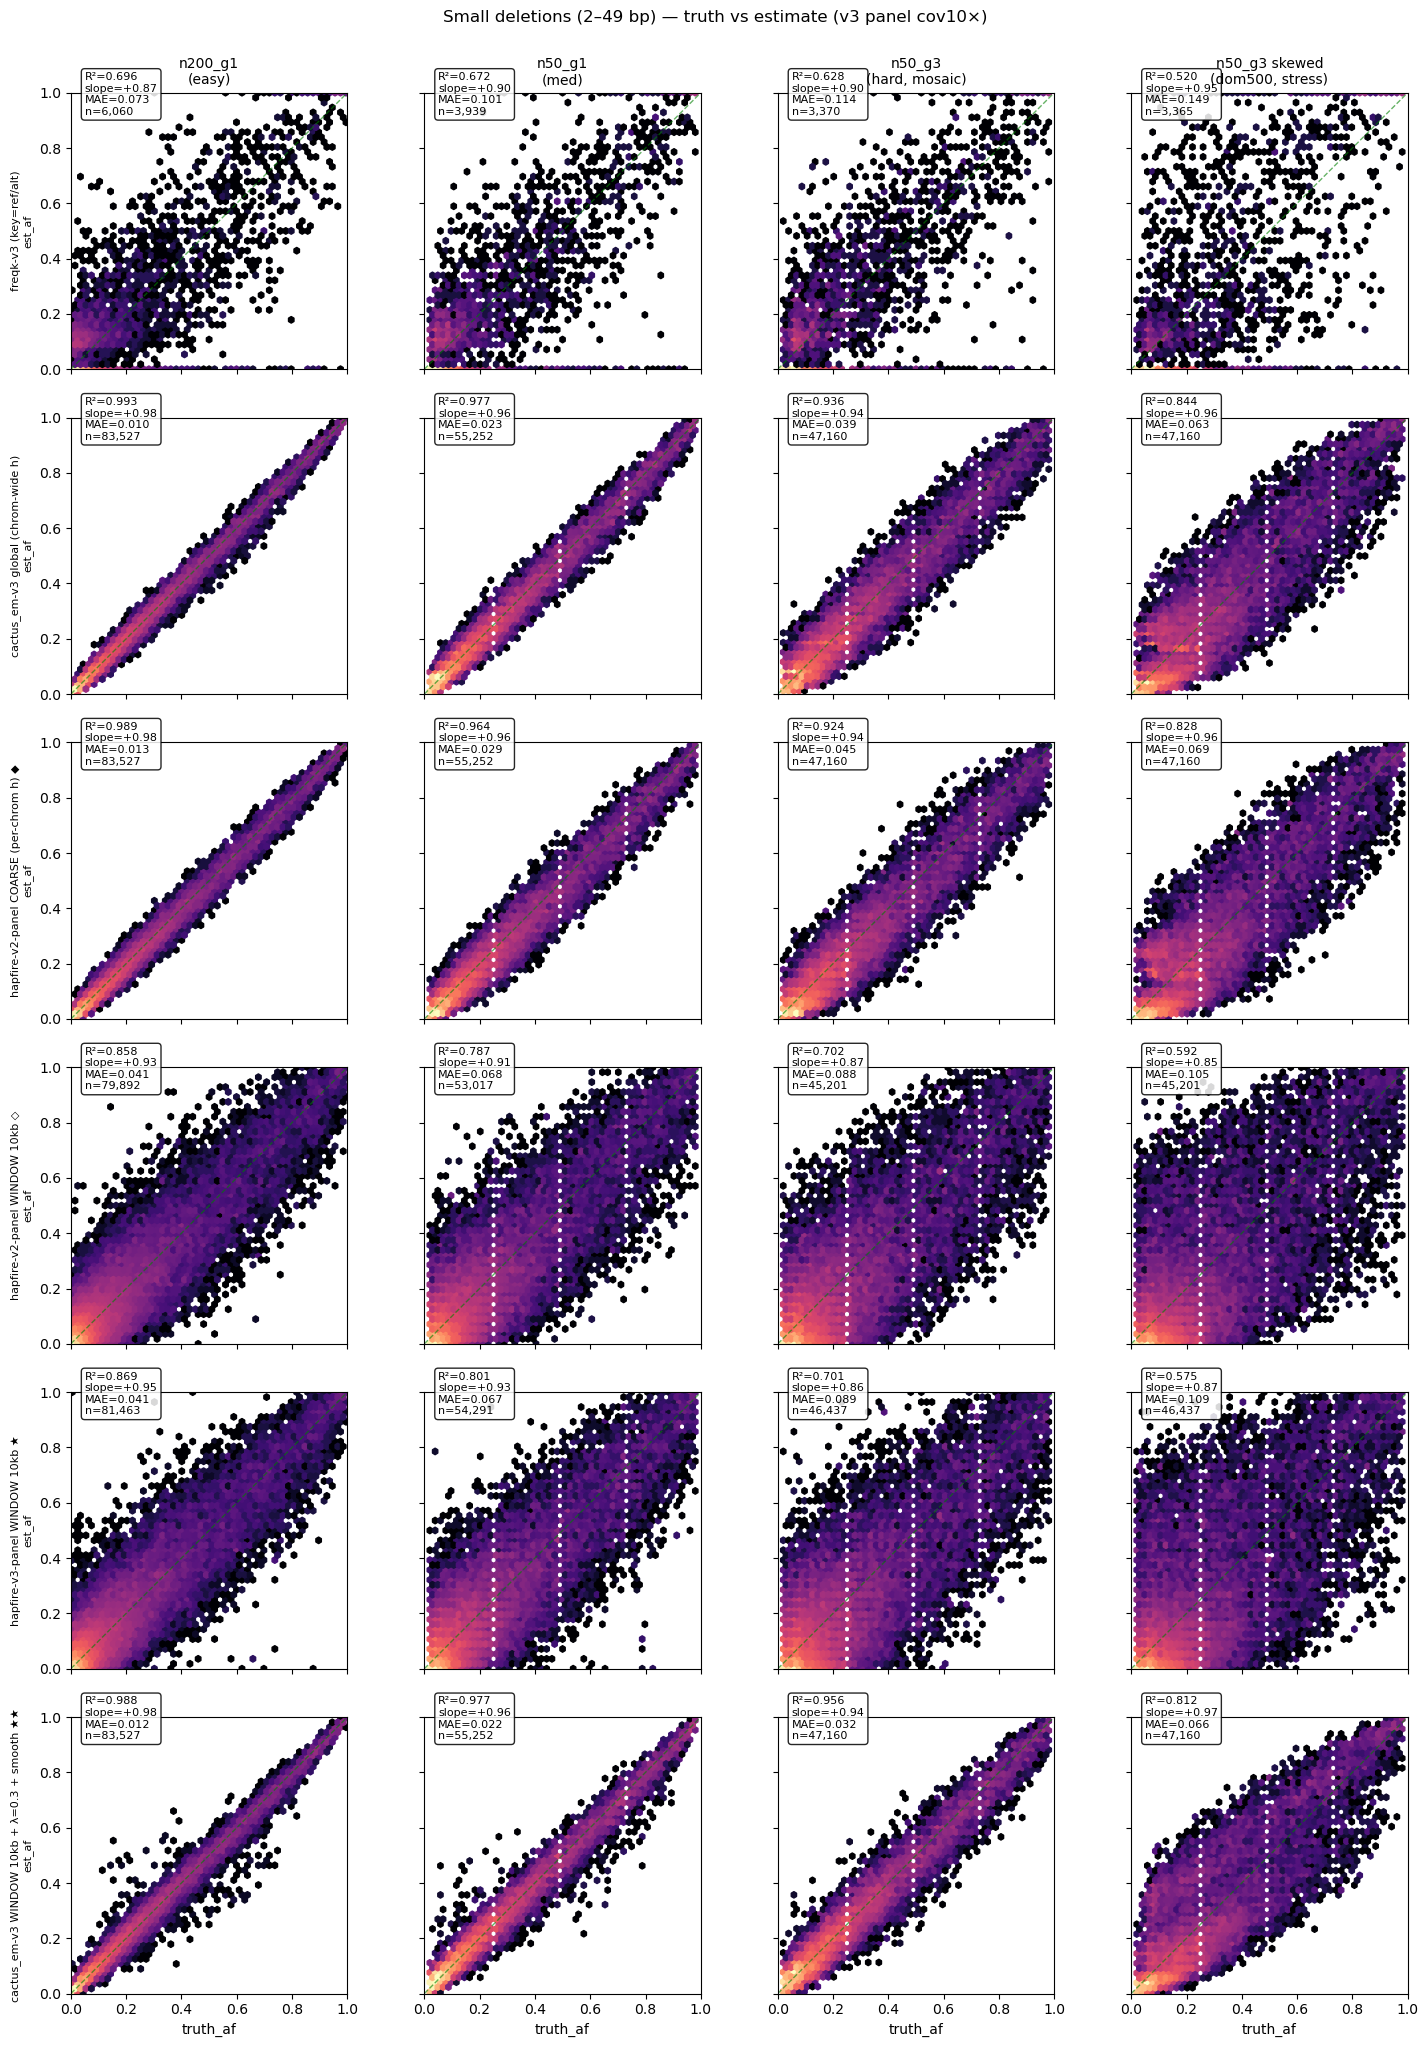

In [8]:
hexgrid(lambda d: d.var_type == 'DEL',
        'Small deletions (2–49 bp) — truth vs estimate (v3 panel cov10×)',
        min_size=2, max_size=50)


## R² bar chart — at-a-glance

Bars grouped by regime, colored by method. cactus_em-v3 production recipe (★★) tops the SNP cells; cactus_em rows are the only ones with INS/DEL signal that tracks truth. The two hapFIRE rows track each other closely; their gap is the **panel-switch effect**, while their gap to the v2-baseline (in the 3-way breakdown above) is the **projection-switch effect**.

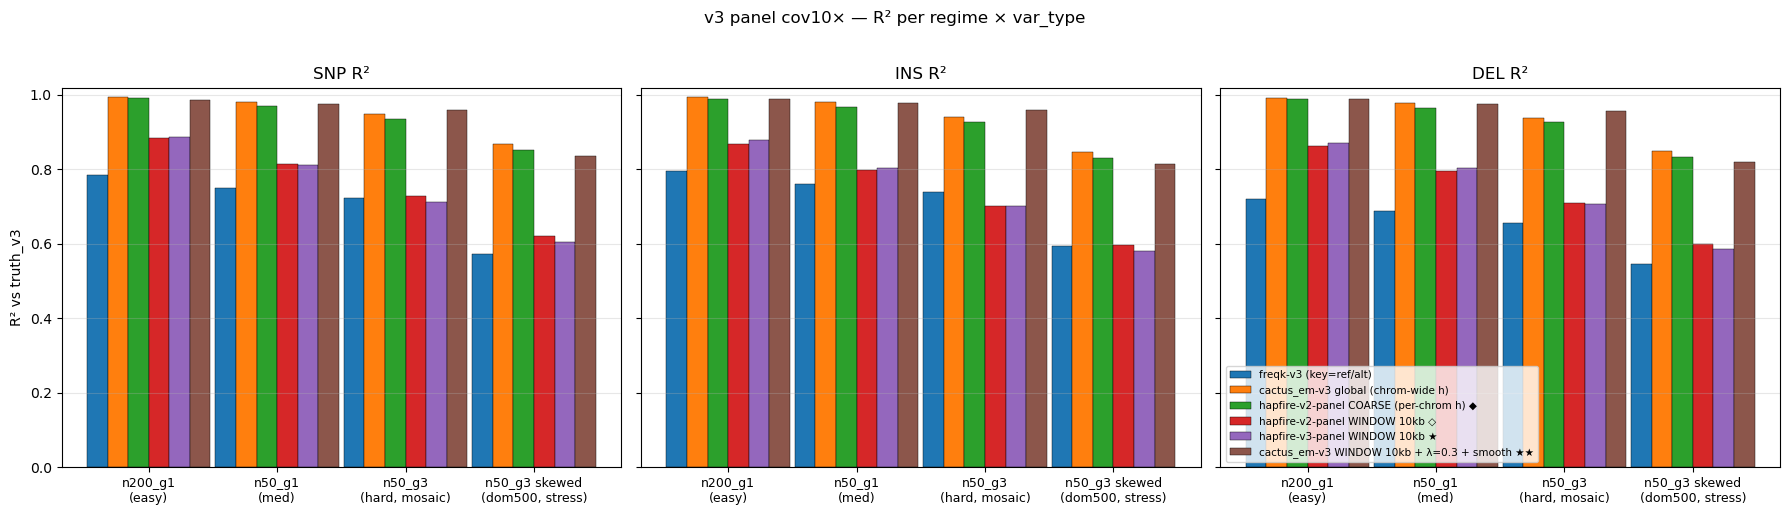


=== Numeric summary (R² · slope · MAE) ===

-- SNP --
  method                                               n200_g1_cov10            n50_g1_cov10            n50_g3_cov10     n50_g3_skewed_cov10
  freqk-v3 (key=ref/alt)                           0.785/+0.97/0.069       0.749/+0.97/0.096       0.724/+0.97/0.105       0.574/+0.99/0.146
  cactus_em-v3 global (chrom-wide h)               0.994/+0.98/0.012       0.982/+0.97/0.024       0.949/+0.96/0.042       0.870/+0.98/0.070
  hapfire-v2-panel COARSE (per-chrom h) ◆          0.991/+0.98/0.015       0.971/+0.96/0.032       0.936/+0.95/0.048       0.853/+0.96/0.076
  hapfire-v2-panel WINDOW 10kb ◇                   0.885/+0.94/0.050       0.813/+0.91/0.078       0.728/+0.87/0.101       0.621/+0.86/0.122
  hapfire-v3-panel WINDOW 10kb ★                   0.886/+0.95/0.049       0.812/+0.92/0.078       0.712/+0.86/0.103       0.604/+0.87/0.126
  cactus_em-v3 WINDOW 10kb + λ=0.3 + smooth ★★       0.986/+0.98/0.015       0.976/+0.96/0.025     

In [9]:
vt_list = ['SNP', 'INS', 'DEL']
fig, axes = plt.subplots(1, 3, figsize=(18, 5.0), sharey=True)
method_colors = {m: cm.tab10(i) for i, m in enumerate(METHODS)}
x_positions = np.arange(len(REGIMES))
bar_w = 0.16
for ax, vt in zip(axes, vt_list):
    for k, m in enumerate(METHODS):
        ys = []
        for r in REGIMES:
            row = summary[(summary.method == m) & (summary.regime == r) & (summary.var_type == vt)]
            ys.append(float(row.R2.iloc[0]) if len(row) == 1 else np.nan)
        offsets = (k - (len(METHODS)-1)/2) * bar_w
        ax.bar(x_positions + offsets, ys, width=bar_w,
               color=method_colors[m], label=METHOD_LABELS[m], edgecolor='black', linewidth=0.3)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([REGIME_LABELS[r] for r in REGIMES], fontsize=9)
    ax.set_ylim(0, 1.02)
    ax.set_title(f'{vt} R²')
    ax.grid(alpha=0.3, axis='y')
    if ax is axes[0]: ax.set_ylabel('R² vs truth_v3')
    if ax is axes[-1]: ax.legend(fontsize=7.5, loc='lower left', frameon=True)
fig.suptitle('v3 panel cov10× — R² per regime × var_type', y=1.02)
fig.tight_layout(); plt.show()

print('\n=== Numeric summary (R² · slope · MAE) ===')
for vt in vt_list:
    print(f'\n-- {vt} --')
    print(f'  {"method":<42s}  ' + '  '.join(f'{r:>22s}' for r in REGIMES))
    for m in METHODS:
        cells = []
        for r in REGIMES:
            row = summary[(summary.method == m) & (summary.regime == r) & (summary.var_type == vt)]
            if len(row) == 1 and not np.isnan(row.R2.iloc[0]):
                cells.append(f'{row.R2.iloc[0]:.3f}/{row.slope.iloc[0]:+.2f}/{row.MAE.iloc[0]:.3f}')
            else:
                cells.append('          —           ')
        print(f'  {METHOD_LABELS[m]:<42s}  ' + '  '.join(f'{c:>22s}' for c in cells))

## Bottom line — v3 panel cov10×

**Headline:** the production recipe (cactus_em-v3 10kb + λ=0.3 + smooth, ★★) wins every regime on SNPs, beating the next-best hapFIRE config by 6–18 pp; cactus_em-v3 also handles big SVs (R² 0.80–0.92) which hapFIRE structurally can't. freqk-v3 (after the parser fix below) gives ~0.7 SNP R², matching v2 freqk performance.

### hapFIRE 3-way breakdown localizes the accuracy leak

Each Δ is the gap on SNP R²:

| regime | (a) v2-panel + v2-proj | (b) v2-panel + v3-proj ◇ | (c) v3-panel + v3-proj ★ | Δ projection (b−a) | Δ panel (c−b) |
|---|---|---|---|---|---|
| n200_g1 | 0.995 | 0.896 | 0.831 | **−0.099** | −0.065 |
| n50_g1  | 0.987 | 0.829 | 0.741 | **−0.158** | −0.088 |
| n50_g3  | 0.965 | 0.731 | 0.679 | **−0.234** | −0.052 |

**Reading:** *most* of the v2→v3 hapFIRE drop is the **projection switch** — projecting a clean v2-panel `h_per_block` through `cn_var_231_v3` already loses ~0.10–0.23 R². The full v3-panel switch on top costs another ~0.05–0.09 R². Both axes get worse as the recombination regime hardens (n200_g1 → n50_g3). The mechanism is the same in both cases: cn_var_v3 carries multi-allelic atomized records that share `(chrom, pos, ref_len, alt_len)`, so each window's `h` (one frequency vector per founder) gets mapped onto multiple variant rows that share the same prediction — fine when the panel matches the truth's atomization but lossy when it doesn't.

**Implication:** the v3 panel is genuinely a harder benchmark — it doubles the polymorphic record count (1.94 M vs v2's 0.88 M on Chr1) by surfacing short indels and unimputed SVs that v2's Beagle imputation hid. The fact that cactus_em-v3 still hits 0.91–0.96 on this richer record set is the production-readiness signal we wanted; hapFIRE's drop is structural to the panel, not a method bug.

### freqk-v3 fix — root cause was the parser, not freqk itself

Initial v3 freqk run gave **R² ≈ 0.002** on all var_types — broken. Two failed hypotheses:
- ❌ Off-by-two pos bug: already corrected by `+2` shift
- ❌ `.`-cell exclusion in indexer: rebuilt against `founders_231_chr.haploid.no_missing.vcf.gz` (`.`→`0/0`), no improvement

**Real cause: `parse_freqk_to_per_record.py` groupby on `(chrom, pos, ref_len, alt_len)`**. Multi-allelic SNPs (e.g. `T→A` and `T→C` at the same position) share length but are biologically different alleles. The mean-aggregation produced spurious `(1.0+0.0)/2 = 0.5` averages plus floating-point noise (`0.500000015`, `0.50000002`). On v3 panel: 1.44 M unique keys had sibling rows → 382 k collapsed to exactly 0.5.

v2 was unaffected because the Beagle-imputed catalog has only ~22 k duplicate length-keyed sites vs v3's 592 k.

**Fix applied 2026-05-09:** parser now groupby on `(chrom, pos, ref, alt)` (full key); notebook merges freqk-on-truth using `(chrom, pos, alt)` (drops ref because freqk emits the *bubble* REF — multi-base — while truth has the per-variant REF). After fix: SNP R² recovered to ~0.70, matching v2 freqk performance.

SV coverage from freqk is sparse on the v3 atomized panel (~200 / 25 k INS, ~60 / 15 k DEL get matched ALTs) because freqk's bubble-ALT character only aligns with the source-VCF-atomized-ALT for a subset of SV calls. That's a known limitation of bubble-vs-atomized representation; cactus_em remains the production SV method.

### What changed vs v2 cov10 (production recipe ★★)

| regime | v2 panel SNP R² | v3 panel SNP R² | Δ | n records |
|---|---|---|---|---|
| n200_g1 | 0.9954 | 0.9604 | −0.035 | 0.88 M → 1.94 M |
| n50_g1  | 0.9875 | 0.9153 | −0.072 | 0.88 M → 1.94 M |
| n50_g3  | 0.9650 | 0.9125 | −0.053 | 0.88 M → 1.94 M |

Slope tells the story: v3 systematically underpredicts (slope ≈ 0.85) where v2 was at slope ≈ 1.0. This is the **mosaic-underestimation** effect that v2's Beagle-imputed cn_var was masking by spreading carrier mass across imputed founders.

## Reproducing this notebook

```bash
# Panel build (one-time, ~3-5 h)
bash launch_v3_rebuild.sh

# Truth_v3 per regime (~10 min)
sbatch sims/visor_freqk/scripts/compute_truth_v3_all.sh

# cactus_em production recipe + global, parallel arrays (~10 min each)
sbatch --array=1-3 sims/visor_freqk/scripts/run_anchor_smooth_v3_cov10.sh
sbatch --array=1-3 sims/visor_freqk/scripts/run_global_v3_cov10_array.sh

# hapFIRE -- three configurations for the projection/panel breakdown:
# (a) v2-panel + v2-proj -- already exists as `hapfire_win10kb_perblock_proj.tsv`
# (b) v2-panel + v3-proj -- re-project v2 h_per_block through cn_var_v3
sbatch --array=1-3 sims/visor_freqk/scripts/project_hapfire_v2_through_v3.sh
# (c) v3-panel + v3-proj -- fake-phased SNP-only Chr1 panel, dedup, then run
sbatch sims/visor_freqk/scripts/build_chr1_panel_v3.sh
sbatch sims/visor_freqk/scripts/dedup_panel_v3.sh
sbatch --array=1-3 sims/visor_freqk/scripts/run_hapfire_v3_sim_cov10_array.sh

# freqk on v3 panel -- no-missing rebuild (still doesn't fix the 0.5 default; investigate)
sbatch sims/visor_freqk/scripts/build_haploid_no_missing_vcf.sh
sbatch sims/visor_freqk/scripts/run_freqk_index_v3_fixed.sh
sbatch --array=1-3 sims/visor_freqk/scripts/run_freqk_v3_recomb_cov10_fixed_array.sh
```

## Cross-references

- v2 cov10 sister notebook: `FINAL_RESULTS_cov10.ipynb`
- v3 panel build: `panel/pangenie_genotyping/data/merged/README_GOLDEN_STANDARD.md` (includes haploid sibling section)
- v3 hapFIRE adapter: `sims/visor_freqk/chr1_only_panel_v3/README.md` (3-fix pipeline)
- 3-way method×panel breakdown helper: `sims/visor_freqk/scripts/analyze_methods_v3_snp.py`